# Where was the strongest mid-level rotation in each two-minute grid, and did it move toward the reported tornado?

MRMS merges every NEXRAD radar onto one fixed CONUS grid every two minutes. The
mid-level rotation track `RotationTrackML30min_00.50` holds, at each grid point,
the largest azimuthal shear seen in the 3 to 6 km layer during the previous
thirty minutes, in units of 0.001 s⁻¹. This notebook pulls eleven of those
grids, 04:30 to 04:50 UTC on 2024-05-07, finds the strongest value in each one,
and measures how far that point lay from Oklahoma Storm Events tornado report
[1184052](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052).
NCEI places that report's path start at 35.378° N, 97.543° W, beginning 22:39
CST on May 6, which is 04:39 UTC on May 7. The same case appears in the
[event context](https://usdata.dev/studies/event-context/) and
[tornado classification](https://usdata.dev/studies/tornado-classification/)
examples.

A rotation track is a radar-derived shear field, not a tornado detection and not
a storm-motion product. Each value is a maximum already accumulated over the
half hour before the file stamp, so a peak marks where the strongest shear
happened at some point in that half hour, not where rotation is at the stamp
itself. The answer below is therefore about where shear maxima sat, not about
whether a tornado was on the ground.

Requires **usdata v0.15.0 or later** with the `grib` extra, plus the examples
environment (`just notebooks`). The eleven files total about 2 MB on disk, and
each one decodes to a 7,000 × 14,000 grid of about 0.4 GB. Run every cell in
order. Saved outputs are a recorded run; retain the manifest, lockfile, and
cached bytes to repeat it.

In [1]:
import gc
import sys
import time
from datetime import UTC, datetime
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd
from pyproj import Geod

from usdata.pull import pull, verify

try:
    import resource
except ImportError:  # Windows has no resource module.
    resource = None
RSS_SCALE = {"linux": 1e6, "darwin": 1e9}.get(sys.platform)


def peak_rss_gb() -> float:
    """High-water resident memory of this process in GB, or NaN where unavailable."""
    if resource is None or RSS_SCALE is None:
        return float("nan")
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / RSS_SCALE


manifest = Path("examples/datasets/noaa-mrms/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")

REPORT_ID = "1184052"
REPORT_LAT, REPORT_LON = 35.378, -97.543
REPORT_UTC = datetime(2024, 5, 7, 4, 39, tzinfo=UTC)
UNITS = "0.001 s⁻¹"
geod = Geod(ellps="WGS84")

pd.set_option("display.max_columns", 12)
print("Executed UTC:", datetime.now(UTC).isoformat(timespec="seconds"))
print("Python:", sys.version.split()[0])
packages = ("usdata", "numpy", "pandas", "xarray", "eccodes", "pyproj")
print({name: version(name) for name in packages})

Executed UTC: 2026-09-15T23:34:20+00:00
Python: 3.14.7
{'usdata': '0.16.0', 'numpy': '2.5.2', 'pandas': '3.0.5', 'xarray': '2026.7.0', 'eccodes': '2.48.0', 'pyproj': '3.8.0'}


## 1. Pin the eleven grids

The manifest names one dataset, one product, and an inclusive UTC window. MRMS
takes no location or bounding box: every file is a whole CONUS grid that the
server cannot crop, so all narrowing happens locally after download. Both bounds
are inclusive and the stamps are on even minutes, so 04:30 through 04:50 selects
eleven files. A query may span at most one day, and the archive starts on
2020-10-14.

The first pull writes `dataset.lock.json` with a checksum per file; later pulls
restore those pins from the cache. `verify` is offline and returns an empty list
when the cached bytes still match the lock.

In [2]:
print(manifest.read_text())
started = time.perf_counter()
result = pull(manifest)
drift = verify(manifest)
assert drift == [], drift
items = sorted(result.fetched, key=lambda item: item.asset.time.start)
assert len(items) == 11, f"expected eleven two-minute grids, got {len(items)}"
assert {item.asset.dataset_id for item in items} == {"noaa:mrms"}
print("Pull seconds:", round(time.perf_counter() - started, 2))
print("Total source bytes:", sum(item.provenance.size for item in items))
print("Restored from lockfile:", result.from_lockfile)
files = pd.DataFrame(
    {
        "grid_utc": item.asset.time.start.strftime("%H:%M"),
        "asset_id": item.asset.id,
        "bytes": item.provenance.size,
        "from_cache": item.from_cache,
    }
    for item in items
)
files

name: oklahoma-rotation-tracks
sources:
  - dataset: noaa:mrms
    start: 2024-05-07T04:30:00Z
    end: 2024-05-07T04:50:00Z
    params:
      product: RotationTrackML30min_00.50



Pull seconds: 1.47
Total source bytes: 2028483
Restored from lockfile: False


,grid_utc,asset_id,bytes,from_cache
0,04:30,MRMS_RotationTrackML30min_00.50_20240507-04300...,192425,False
1,04:32,MRMS_RotationTrackML30min_00.50_20240507-04320...,187260,False
2,04:34,MRMS_RotationTrackML30min_00.50_20240507-04340...,187420,False
3,04:36,MRMS_RotationTrackML30min_00.50_20240507-04360...,188309,False
4,04:38,MRMS_RotationTrackML30min_00.50_20240507-04380...,182758,False
5,04:40,MRMS_RotationTrackML30min_00.50_20240507-04400...,184277,False
6,04:42,MRMS_RotationTrackML30min_00.50_20240507-04420...,184212,False
7,04:44,MRMS_RotationTrackML30min_00.50_20240507-04440...,181434,False
8,04:46,MRMS_RotationTrackML30min_00.50_20240507-04460...,180739,False
9,04:48,MRMS_RotationTrackML30min_00.50_20240507-04480...,182037,False


## 2. What one grid contains

Open the 04:30 file and look before computing anything. The grid is 0.005°,
7,000 rows by 14,000 columns, 98 million points held as float32. Rows run north
to south and longitudes keep the file's 0 to 360 convention, so a slice for
Oklahoma runs from the higher latitude to the lower one and adds 360 to a
negative longitude.

Two things the documentation does not prepare you for show up here. ecCodes has
no parameter table for MRMS, so the reader names the variable from the product
segment of the file name, `RotationTrackML30min` without the `_00.50` suffix,
and the `units` attribute reads `unknown`; the units come from the
[provider notes](https://docs.usdata.dev/providers/noaa-mrms/), not the file.
And this product carries no `-999` or `-99` sentinels and no NaN at all: every
point without reported shear is exactly 0.0, so no coverage and no rotation look
identical. Values are whole numbers, which matters later because many points tie
at the maximum.

The cell also records resident memory around the decode. usdata offers no way to
ask how large a decode will be, so this is measured with the platform's own
counter.

In [3]:
rss_before = peak_rss_gb()
started = time.perf_counter()
grid = items[0].open()
open_seconds = time.perf_counter() - started
rss_after = peak_rss_gb()
(variable,) = grid.data_vars
field = grid[variable]
values = field.values

print("Variable:", variable, "· units attribute:", field.attrs.get("units"))
print("Shape:", field.shape, "· dtype:", field.dtype, "· decoded GB:", round(field.nbytes / 1e9, 3))
print("Open seconds:", round(open_seconds, 2))
print("Peak RSS GB before/after one open:", round(rss_before, 2), "->", round(rss_after, 2))
print("Latitude from", float(field.latitude[0]), "to", float(field.latitude[-1]))
print("Longitude from", float(field.longitude[0]), "to", float(field.longitude[-1]))
print("Grid spacing (degrees):", round(float(field.latitude[0] - field.latitude[1]), 4))
print("NaN points:", int(np.isnan(values).sum()), "· negative points:", int((values < 0).sum()))
print("Points above zero:", int((values > 0).sum()), "of", values.size)
print("Whole numbers only:", bool(np.array_equal(values, np.round(values))))
print(f"CONUS maximum: {values.max():.0f} ({UNITS})")
conus_row, conus_col = np.unravel_index(int(values.argmax()), values.shape)
print(
    "CONUS maximum at",
    f"{float(field.latitude[conus_row]):.3f}° N",
    f"{float(field.longitude[conus_col]) - 360:.3f}° E",
)
del grid, field, values
gc.collect();

Variable: RotationTrackML30min · units attribute: unknown
Shape: (7000, 14000) · dtype: float32 · decoded GB: 0.392
Open seconds: 1.23
Peak RSS GB before/after one open: 0.14 -> 1.34
Latitude from 54.9975 to 20.002500000000005
Longitude from 230.0025 to 299.9975
Grid spacing (degrees): 0.005
NaN points: 0 · negative points: 0
Points above zero: 186835 of 98000000


Whole numbers only: True
CONUS maximum: 30 (0.001 s⁻¹)
CONUS maximum at 49.242° N -124.188° E


## 3. Two neighbourhoods around the report

The CONUS maximum above sits on the Pacific coast, nowhere near Oklahoma, so
"the strongest rotation in the grid" only means something inside a stated
neighbourhood. This notebook uses two, both centred on the report's path start:

- a **search box** of ±1.0° in latitude and longitude, about 222 by 182 km,
  wide enough to hold more than one rotation area, which answers "where was the
  strongest rotation near the report" without assuming which storm produced it;
- a **storm box** of ±0.25°, about 55 by 45 km, tight enough that a maximum
  inside it is close enough to the report to plausibly belong to the same
  storm.

Because values are whole numbers, several points usually tie at a box maximum.
Taking `argmax` would pick one of them by array order, so each peak position
below is the mean latitude and longitude of every tied point, with the tie count
kept in the table. Distances are WGS84 geodesic distances from the report's path
start.

Each grid is decoded, cropped, and released one at a time. The crops are small;
the decoded grids are not, and the high-water memory printed after the loop is
well above one grid, so a machine running this needs headroom beyond the 0.4 GB
a single grid occupies.

In [4]:
SEARCH_HALF, STORM_HALF = 1.0, 0.25


def box_of(field, half: float):
    """The square of half-degree radius around the report, in the file's own frame."""
    return field.sel(
        latitude=slice(REPORT_LAT + half, REPORT_LAT - half),
        longitude=slice(REPORT_LON + 360 - half, REPORT_LON + 360 + half),
    )


def peak_of(box) -> dict:
    """Box maximum, how many points tie at it, and the tied points' mean position."""
    array = box.values
    top = float(array.max())
    rows, cols = np.nonzero(array >= top)
    lat = float(box.latitude.values[rows].mean())
    lon = float(box.longitude.values[cols].mean()) - 360
    _, _, metres = geod.inv(REPORT_LON, REPORT_LAT, lon, lat)
    return {"peak": top, "tied": len(rows), "lat": lat, "lon": lon, "km": metres / 1000}


north, south = REPORT_LAT + SEARCH_HALF, REPORT_LAT - SEARCH_HALF
west, east = REPORT_LON - SEARCH_HALF, REPORT_LON + SEARCH_HALF
_, _, height_m = geod.inv(REPORT_LON, south, REPORT_LON, north)
_, _, width_m = geod.inv(west, REPORT_LAT, east, REPORT_LAT)
print(f"Search box: {height_m / 1000:.0f} km north to south, {width_m / 1000:.0f} km west to east")

rows = []
crops = {}
started = time.perf_counter()
for item in items:
    grid = item.open()
    (variable,) = grid.data_vars
    crop = box_of(grid[variable], SEARCH_HALF).load()
    del grid
    gc.collect()
    wide = peak_of(crop)
    near = peak_of(box_of(crop, STORM_HALF))
    stamp = item.asset.time.start
    crops[stamp] = crop
    rows.append(
        {
            "grid_utc": stamp.strftime("%H:%M"),
            "search_peak": wide["peak"],
            "tied_points": wide["tied"],
            "peak_lat": round(wide["lat"], 3),
            "peak_lon": round(wide["lon"], 3),
            "peak_km_from_report": round(wide["km"], 1),
            "storm_peak": near["peak"],
            "storm_km_from_report": round(near["km"], 1),
        }
    )
table = pd.DataFrame(rows)
print("Decode and crop seconds:", round(time.perf_counter() - started, 1))
print("Cropped points kept per grid:", crops[max(crops)].size)
print("Peak RSS GB after eleven decodes:", round(peak_rss_gb(), 2))
table

Search box: 222 km north to south, 182 km west to east


Decode and crop seconds: 6.8
Cropped points kept per grid: 160000
Peak RSS GB after eleven decodes: 5.28


,grid_utc,search_peak,tied_points,peak_lat,peak_lon,peak_km_from_report,storm_peak,storm_km_from_report
0,04:30,22.0,3,35.794,-97.038,65.0,13.0,19.4
1,04:32,22.0,3,35.794,-97.038,65.0,13.0,19.4
2,04:34,22.0,3,35.794,-97.038,65.0,13.0,19.4
3,04:36,22.0,3,35.794,-97.038,65.0,13.0,16.3
4,04:38,20.0,12,35.741,-96.899,70.9,13.0,16.3
5,04:40,20.0,12,35.741,-96.899,70.9,13.0,16.3
6,04:42,20.0,1,35.737,-96.897,70.8,18.0,0.1
7,04:44,19.0,10,35.680,-96.746,79.7,18.0,0.1
8,04:46,19.0,10,35.680,-96.746,79.7,18.0,0.1
9,04:48,19.0,10,35.680,-96.746,79.7,18.0,0.1


## 4. The track those peaks trace

The map draws the 04:50 grid, whose thirty-minute accumulation covers most of
this window, with zeros left blank. On top of it are the eleven search-box peak
positions in time order, the storm box, and the reported path start. The lower
panel plots both box maxima and the distance from the report to the search-box
peak.

Consecutive grids often repeat a position exactly. That is the accumulation at
work: as long as the half-hour window still contains the same historical
maximum, the peak does not move, and it jumps when that maximum ages out. The
jumps here fall at 04:38 and 04:44. If the window is exactly the preceding
thirty minutes, the values they replaced were set in the two minutes before
04:08 and before 04:14, which is earlier than any grid in this window.

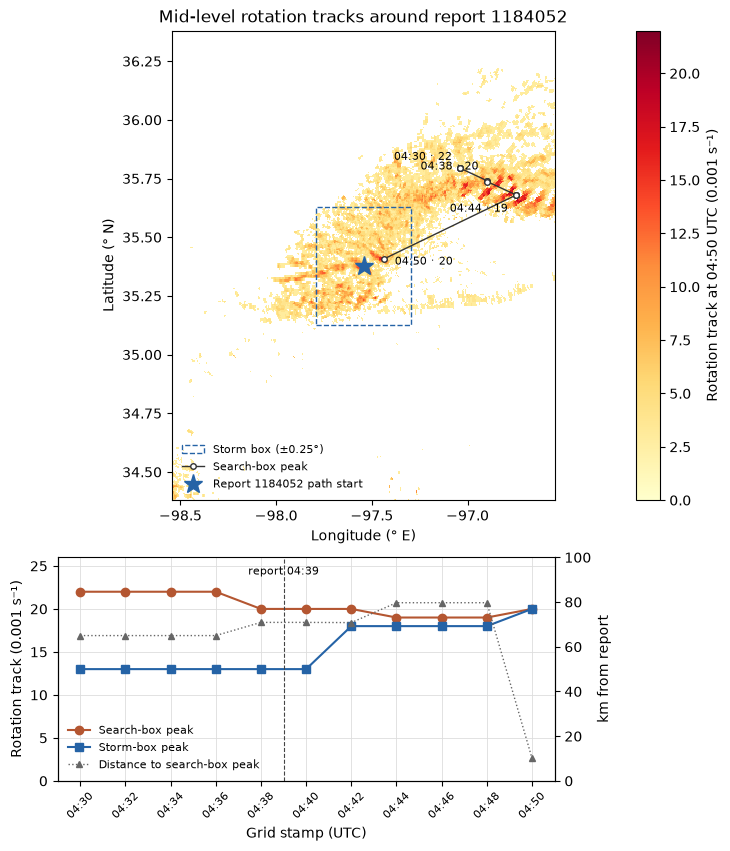

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator

background = crops[max(crops)]
shown = background.where(background > 0)
lons = background.longitude.values - 360
lats = background.latitude.values

fig = plt.figure(figsize=(7.2, 8.4), layout="constrained")
axes = fig.subplot_mosaic([["map"], ["series"]], height_ratios=[2.1, 1.0])
ax = axes["map"]
mesh = ax.pcolormesh(lons, lats, shown.values, cmap="YlOrRd", vmin=0, vmax=22, shading="nearest")
fig.colorbar(mesh, ax=ax, label=f"Rotation track at {max(crops):%H:%M} UTC ({UNITS})")
ax.add_patch(
    Rectangle(
        (REPORT_LON - STORM_HALF, REPORT_LAT - STORM_HALF),
        2 * STORM_HALF,
        2 * STORM_HALF,
        fill=False,
        edgecolor="#2563a6",
        linewidth=1.0,
        linestyle="--",
        label="Storm box (±0.25°)",
    )
)
ax.plot(
    table.peak_lon,
    table.peak_lat,
    color="#333333",
    linewidth=1.0,
    marker="o",
    markersize=4,
    markerfacecolor="white",
    label="Search-box peak",
)
callouts = {
    "04:30": ((-6, 6), "right"),
    "04:38": ((-6, 8), "right"),
    "04:44": ((-6, -12), "right"),
    "04:50": ((8, -4), "left"),
}
for label, (offset, align) in callouts.items():
    point = table.loc[table.grid_utc.eq(label)].iloc[0]
    ax.annotate(
        f"{label} · {point.search_peak:.0f}",
        (point.peak_lon, point.peak_lat),
        textcoords="offset points",
        xytext=offset,
        ha=align,
        fontsize=8,
    )
ax.plot(
    REPORT_LON,
    REPORT_LAT,
    marker="*",
    markersize=14,
    color="#2563a6",
    linestyle="none",
    label=f"Report {REPORT_ID} path start",
)
ax.set(
    title=f"Mid-level rotation tracks around report {REPORT_ID}",
    xlabel="Longitude (° E)",
    ylabel="Latitude (° N)",
)
ax.set_aspect(1 / np.cos(np.deg2rad(REPORT_LAT)))
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.legend(loc="lower left", frameon=False, fontsize=8)

series = axes["series"]
steps = np.arange(len(table))
report_step = (REPORT_UTC - min(crops)).total_seconds() / 120
series.plot(steps, table.search_peak, color="#b45631", marker="o", label="Search-box peak")
series.plot(steps, table.storm_peak, color="#2563a6", marker="s", label="Storm-box peak")
series.set(ylabel=f"Rotation track ({UNITS})", xlabel="Grid stamp (UTC)", ylim=(0, 26))
series.set_xticks(steps, table.grid_utc, rotation=45, fontsize=8)
series.axvline(report_step, color="#444444", linewidth=0.8, linestyle="--")
series.annotate("report 04:39", (report_step, 24), fontsize=8, ha="center")
distance = series.twinx()
distance.plot(
    steps,
    table.peak_km_from_report,
    color="#666666",
    linewidth=1.0,
    linestyle=":",
    marker="^",
    markersize=4,
    label="Distance to search-box peak",
)
distance.set(ylabel="km from report", ylim=(0, 100))
series.grid(color="#dddddd", linewidth=0.6)
series.spines[["top"]].set_visible(False)
handles = series.get_legend_handles_labels()[0] + distance.get_legend_handles_labels()[0]
labels = series.get_legend_handles_labels()[1] + distance.get_legend_handles_labels()[1]
series.legend(handles, labels, loc="lower left", frameon=False, fontsize=8)
plt.show()

## 5. What the eleven grids show, and what they do not

Two rotation areas sit inside the search box. The stronger one is 65 to 80 km
east-northeast of the report, too far away to be the same circulation, and it
weakens from 22 to 19 (0.001 s⁻¹) while stepping further east-northeast. In ten
of the eleven grids the search-box maximum therefore moves away from the report
rather than toward it. The maximum inside the storm box rises from 13 to 20 over
the same window, and from 04:42 to 04:48 it sits 0.1 km from the reported path
start. At 04:50 that nearby feature becomes the strongest value in the whole
search box, 10 km from the report, the one grid in which the two boxes give the
same answer.

What this does not show: whether a tornado was on the ground, which storm any
value belongs to (the boxes are an assumption, not a storm identification), or
anything about the low-level circulation, since this product is the 3 to 6 km
layer. Azimuthal shear depends on radar range and viewing angle, and mid-level
values are routinely high in supercells that produce no tornado. The report
itself is a human account with an approximate position and time, and the grid
stamps are the end of each accumulation, not observation times.

In [6]:
first, last = table.iloc[0], table.iloc[-1]
closest = table.loc[table.peak_km_from_report.idxmin()]
nearest_storm = table.loc[table.storm_km_from_report.idxmin()]
print(
    f"Search-box peak went from {first.search_peak:.0f} ({UNITS}) at {first.grid_utc} UTC, "
    f"{first.peak_km_from_report:.0f} km from the report, to {last.search_peak:.0f} at "
    f"{last.grid_utc} UTC, {last.peak_km_from_report:.0f} km away."
)
print(
    f"Its farthest position was {table.peak_km_from_report.max():.0f} km out; "
    f"the closest was {closest.peak_km_from_report:.0f} km at {closest.grid_utc} UTC."
)
print(
    f"Storm-box peak rose from {table.storm_peak.iloc[0]:.0f} to {table.storm_peak.iloc[-1]:.0f} "
    f"({UNITS}), and from {nearest_storm.grid_utc} UTC it sat "
    f"{nearest_storm.storm_km_from_report:.1f} km from the reported path start."
)
print(
    f"Distinct search-box peak positions across eleven grids: "
    f"{len(table[['peak_lat', 'peak_lon']].drop_duplicates())}; "
    f"points tied at a maximum: {table.tied_points.min()} to {table.tied_points.max()}."
)
print(
    "Scope: one MRMS product, eleven grids, two boxes chosen here, "
    f"one Storm Events report at {REPORT_UTC:%H:%M} UTC."
)

Search-box peak went from 22 (0.001 s⁻¹) at 04:30 UTC, 65 km from the report, to 20 at 04:50 UTC, 10 km away.
Its farthest position was 80 km out; the closest was 10 km at 04:50 UTC.
Storm-box peak rose from 13 to 20 (0.001 s⁻¹), and from 04:42 UTC it sat 0.1 km from the reported path start.
Distinct search-box peak positions across eleven grids: 5; points tied at a maximum: 1 to 12.
Scope: one MRMS product, eleven grids, two boxes chosen here, one Storm Events report at 04:39 UTC.


## 6. Verify, and expect revisions

Verification is offline: it compares the manifest and the cached bytes with the
lockfile. A second pull restores the same eleven pinned files from the cache
without listing the bucket again.

MRMS files in `noaa-mrms-pds` are published once and not normally rewritten, but
a lockfile is what tells you if that changes. A restore whose bytes no longer
match exits 4 and rewrites nothing; accept new bytes deliberately with
`usdata pull dataset.yaml --update noaa:mrms`, or `pull(manifest,
update=["noaa:mrms"])`, and rerun the analysis. A lockfile detects changed data;
it does not archive it, so keep the cached bytes alongside the manifest.

In [7]:
again = pull(manifest)
print("Verification drift:", verify(manifest))
print("Restored from lockfile:", again.from_lockfile)
print("All assets came from cache:", all(item.from_cache for item in again.fetched))
print("Locked assets:", len(again.fetched))

Verification drift: []
Restored from lockfile: True
All assets came from cache: True
Locked assets: 11
